<a href="https://colab.research.google.com/github/akarshroot/enhancing-imitation-game/blob/main/enhancing_the_imitation_game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Download the Dataset and Install Dependencies**

In [ ]:
# !curl "https://docs.google.com/spreadsheets/d/11TArvDlY6ZA6P_3kSMdqYBKdfIc0NArvFEJjYY5_XH0/edit?usp=share_link"
# !pip install language-checker
!pip install language-tool-python
!pip install text2emotion
!pip install emoji==1.7.0
import nltk
nltk.download('punkt')

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.3/356.3 kB 22.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-2.5.1-py2.py3-none-any.whl size=351210 sha256=d1d7acc05ded0fe4c471b00b1d3708706f63e754463072e399c7a66923c1c8ea
  Stored in directory: /root/.cache/pip/wheels/51/92/44/e2ef13f803aa08711819357e6de0c5fe67b874671141413565
Successfully built emoji
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171033 sha256=facb074b79

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## **Imports and Data Loading**
Import pandas and create a dataframe from the dataset

In [ ]:
import pandas as pd
import language_tool_python
tool = language_tool_python.LanguageTool('en-US')

INFO:language_tool_python.download_lt:Unzipping /tmp/tmppz9gwv7c.zip to /root/.cache/language_tool_python.
INFO:language_tool_python.download_lt:Downloaded https://www.languagetool.org/download/LanguageTool-5.7.zip to /root/.cache/language_tool_python.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Research/all_results.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50134 entries, 0 to 50133
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Question #                           50134 non-null  int64  
 1   Question                             50134 non-null  object 
 2   Keywords                             50134 non-null  object 
 3   Unfiltered Answer                    50134 non-null  object 
 4   Unfiltered Answer Length (in words)  50134 non-null  int64  
 5   Thinking Time (in milliseconds)      50134 non-null  float64
 6   Response Time (in seconds)           50134 non-null  float64
 7   Filtered Answer                      50134 non-null  object 
 8   Grammatical Errors                   50134 non-null  float64
 9   Human-like Phrases                   50134 non-null  float64
 10  Response Time                        50134 non-null  float64
 11  Detail Handling             

## Setting Constants

In [ ]:
DETAIL_CONSTANT = 2 #How many words in response per word in question
PATTERN_TONE_CONSTANT = 0.2 #Difference in tone between any two consecutive questions
STANDARD_WPS = 5 #Average typing/speaking speed of a human in words per second
GRAMMAR_ERROR_PERCENTAGE = 10

## **Filter Responses**
Filter the responses to remove any phrases or sentences where AI/machine obligatory describes itself as a machine.

In [ ]:
def filter(response):
  if(type(response) != str) :
    return "NA"
  if ("As an AI language model" in response) and ("However," in response):
    if(response.split("However,")[0] != None):
      return response.split("However,")[1]
  elif ("As an AI language model, " in response): #experimental
    return response.split('As an AI language model', 1)[1]
  elif ("AI language model, " in response):
    return response.split("AI language model, ", 1)[1]
  else:
    return response

Apply the filter function on unfiltered answers to generate filtered answers and store them in the "Filtered Answers" column

In [ ]:
df = df.fillna("NA")

In [ ]:
df['Filtered Answer'] = df['Unfiltered Answer'].apply(filter)

In [ ]:
df

,Question #,Question,Keywords,Unfiltered Answer,Unfiltered Answer Length (in words),Thinking Time (in milliseconds),Response Time (in seconds),Filtered Answer
0,1,"Can you tell me about Mr. Narendra Modi, the c...","Mr. Narendra Modi, Prime Minister, India",Sure! Mr. Narendra Modi is the current Prime M...,84,265.0,1.200,Sure! Mr. Narendra Modi is the current Prime M...
1,2,Can you tell me about Mr. Abraham Lincoln?,Mr. Abraham Lincoln,Certainly! Mr. Abraham Lincoln was the 16th Pr...,91,350.0,1.400,Certainly! Mr. Abraham Lincoln was the 16th Pr...
2,3,"If I spend 10 hours a day sleeping, 2 eating a...","10 hours, sleeping, 2 hours, eating, 5 hours, ...","If you spend 10 hours sleeping, 2 hours eating...",27,145.0,1.100,"If you spend 10 hours sleeping, 2 hours eating..."
3,4,Two birds sit before a bird and two birds sit ...,"Two birds, sit before, bird, two birds, sit af...",If we assume that there is only one bird sitti...,109,458.0,1.200,If we assume that there is only one bird sitti...
4,5,There’s a one-story house in which everything ...,"one-story house, yellow, walls, yellow, doors,...",If the house is one-story and everything insid...,34,231.0,1.100,If the house is one-story and everything insid...
...,...,...,...,...,...,...,...,...
50129,50130,Can I sort faster if I convert strings to numb...,string number,"As an AI language model, I don't have personal...",98,10568.0,10.570,"in most programming languages, sorting is typ..."
50130,50131,"If I have converted to Islam, and I feel like ...","previous faith, islam","Yes, as an AI language model, I do not have re...",77,8472.0,8.473,"I do not have religious beliefs or opinions, a..."
50131,50132,"Is it true that the new INR 2,000 notes will b...","true new inr note, nano gps chip","No, it is not true. There has been no official...",50,6067.0,6.068,"No, it is not true. There has been no official..."
50132,50133,How can I get my resume shortlisted by Google ...,"google position software engineer, resume",There are a few tips to increase your chances ...,222,22775.0,22.778,There are a few tips to increase your chances ...


## **Factor Calculation Methods**

### Gramatical Errors

In [ ]:
from IPython.display import clear_output

x = 0
def grammatical_errors_calculator(response) :
  matches = tool.check(response)
  clear_output(wait=True)
  global x
  x += 1
  if(len(matches) >= (GRAMMAR_ERROR_PERCENTAGE/100)*len(response.split('.'))):
    return 0
  else:
    return 0.1

In [ ]:
df['Grammatical Errors'] = df['Filtered Answer'].apply(grammatical_errors_calculator)

KeyboardInterrupt: ignored

In [ ]:
df.to_csv("gramatical_err.csv", index=False)
!cp gramatical_err.csv /content/drive/MyDrive/Research/gramatical_err.csv

In [ ]:
df['Grammatical Errors'].value_counts()

0.1    35694
0.0    14440
Name: Grammatical Errors, dtype: int64

### Human-like Phrases

In [ ]:
import re
human_phrases = pd.read_csv('/content/drive/MyDrive/Research/human_phrases.csv')

def count_human_phrases(response):
  count = 0
  for phrase in human_phrases:
    if re.search(phrase, response, re.IGNORECASE):
      count += 1
  human_phrases_factor = (count/len(human_phrases))/10
  return human_phrases_factor

In [ ]:
df["Human-like Phrases"] = df["Filtered Answer"].apply(count_human_phrases)

In [ ]:
df["Human-like Phrases"].value_counts()

0.000000    49793
0.000592      341
Name: Human-like Phrases, dtype: int64

### Response Time

In [ ]:
from nltk.tokenize import wordpunct_tokenize

def response_time(response, thinking_time, total_response_time):
  if type(total_response_time) is str:
    return 0
  tokens = wordpunct_tokenize(response)
  if len(tokens)/total_response_time > STANDARD_WPS:
    return 0
  return 0.1

In [ ]:
df['Response Time'] = df.apply(lambda x : response_time(x['Filtered Answer'], x['Thinking Time (in milliseconds)'], x['Response Time (in seconds)']), axis=1)

In [ ]:
df['Response Time'].value_counts()

0.0    49239
0.1      895
Name: Response Time, dtype: int64

### Detail Handling

In [ ]:
def detail_handling(response, question):
  res_tokens = response.split(" ")
  ques_tokens = question.split(" ")
  ratio = len(res_tokens)/len(ques_tokens)
  if(ratio > DETAIL_CONSTANT):
    return 0
  return 0.1

In [ ]:
df['Detail Handling'] = df.apply(lambda x : detail_handling(x['Filtered Answer'], x['Question']), axis=1)

In [ ]:
df['Detail Handling'].value_counts()

0.0    47146
0.1     2988
Name: Detail Handling, dtype: int64

### Relevancy

In [ ]:
def relevancy(response, keywords):
  count = 0
  for keyword in keywords:
    if keyword in response:
      count += 1
  relevance_ratio = (count/len(keywords))/10
  return relevance_ratio

In [ ]:
df['Relevancy'] = df.apply(lambda x : relevancy(x['Filtered Answer'], x['Keywords']), axis=1)

In [ ]:
df['Relevancy'].value_counts()

0.100000    44079
0.094737      157
0.092857      156
0.095000      155
0.090909      154
            ...  
0.096053        1
0.093651        1
0.053125        1
0.012500        1
0.094231        1
Name: Relevancy, Length: 369, dtype: int64

In [ ]:
df.to_csv("except_creativity.csv", index=False)
!cp except_creativity.csv /content/drive/MyDrive/Research/except_creativity.csv

### Creativity

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.translate import meteor_score
def creativity(response, prev_response):
  if prev_response is None:
    prev_response = ""
  response = word_tokenize(response)
  prev_response = word_tokenize(prev_response)
  similarity_score = meteor_score.single_meteor_score(prev_response, response)
  creativity = (1 - similarity_score)/10 #creativity is the measure of non similarity
  return creativity

In [ ]:
# #INCOMPLETE Alternate method with all responses as reference
# from nltk.tokenize import word_tokenize
# from nltk.translate import meteor_score
# def creativity(response, prev_responses):
#   if prev_response is None:
#     prev_response = ""
#   response = word_tokenize(response)
#   similarity_score = meteor_score.single_meteor_score(prev_responses, response)
#   creativity = (1 - similarity_score)/10 #creativity is the measure of non similarity
#   return creativity

# df['Prev Answer'] = df['Filtered Answer'].shift(1)
# df['Creativity'] = df.apply(lambda x : creativity(x['Filtered Answer'], df['Prev Answer'][]), axis=1)

In [ ]:
df['Prev Answer'] = df['Filtered Answer'].shift(1) #To bring previous responses to the same row, we add a new column
df['Creativity'] = df.apply(lambda x : creativity(x['Filtered Answer'], x['Prev Answer']), axis=1)

In [ ]:
df.to_csv("creativity.csv", index=False)
!cp creativity.csv /content/drive/MyDrive/Research/creativity.csv

### Pattern Matching

In [ ]:
!pip install NRCLex

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
INFO: pip is looking at multiple versions of nrclex to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for NRCLex: filename=NRCLex-3.0.0-py3-none-any.whl size=43308 sha256=d7116180c8f0cb921b06c1a37cca925ddec37c65fbfe77f83d6d7749b4b46d9d
  Stored in directory: /root/.cache/pip/wheels/d2/10/44/6abfb1234298806a145fd6bcaec8cbc712e88dd1cd6cb242fa
Successfully built NRCLex


In [ ]:
from IPython.display import clear_output

x = 0
def pattern_match(response, prev_response):
  clear_output(wait=True)
  global x
  x += 1
  print("Processing Question: " + str(x))
  if prev_response is None:
    return 1
  current_tone = NRCLex(response)
  prev_tone = NRCLex(prev_response)
  # current_tone = te.get_emotion(response)
  # prev_tone = te.get_emotion(prev_response)
  for key in current_tone.raw_emotion_scores:
    value = current_tone.raw_emotion_scores[key]
    score_sum = 0
    if(key in prev_tone.raw_emotion_scores):
      if abs(value - prev_tone.raw_emotion_scores[key]) > PATTERN_TONE_CONSTANT:
        return 0
    else:
      return 0
  return 0.1

In [ ]:
# pattern_match(df['Filtered Answer'][1], df['Prev Answer'][0])

In [ ]:
df['Pattern Matching'] = df.apply(lambda x : pattern_match(x['Filtered Answer'], x['Prev Answer']), axis=1)

Processing Question: 50134


In [ ]:
df.to_csv("pattern.csv", index=False)
!cp pattern.csv /content/drive/MyDrive/Research/pattern.csv

### Opinion Forming

In [ ]:
import re
opinion_keywords = pd.read_csv('/content/drive/MyDrive/Research/opinion_keywords.csv')
def contains_opinion(response):
    # Check if any opinion keyword is present in the text
    count = 0
    for keyword in opinion_keywords:
        if re.search(keyword, response, re.IGNORECASE):
            count += 1
    opinion_factor = (count/len(opinion_keywords))/10
    return opinion_factor

In [ ]:
df['Opinion Forming'] = df['Filtered Answer'].apply(contains_opinion)

In [ ]:
df['Opinion Forming'].value_counts()

0.000000    50113
0.000806       21
Name: Opinion Forming, dtype: int64

In [ ]:
df.to_csv("all_factors.csv", index=False)
!cp all_factors.csv /content/drive/MyDrive/Research/all_factors.csv

## Calculation of Unweighted Trust Factor

In [ ]:
TOTAL_FACTORS_INCORPORATED = 8
def calculate_trust(gramatical_errors, detail_handling, human_phrases, response_time, creativity, relevancy, pattern_matching, opinion_forming):
  factor_sum =  gramatical_errors + detail_handling + human_phrases + response_time + creativity + relevancy + pattern_matching + opinion_forming
  unweighted_trust = factor_sum/TOTAL_FACTORS_INCORPORATED
  return unweighted_trust

In [ ]:
df['Trust Factor'] = df.apply(lambda x : calculate_trust(x['Grammatical Errors'], x['Detail Handling'], x['Human-like Phrases'], x['Response Time'], x['Creativity'], x['Relevancy'], x['Pattern Matching'], x['Opinion Forming']), axis=1)

## Calculate probability of player

In [ ]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [ ]:
alpha = 0.5
def probability(trust_factor):
  global alpha
  if trust_factor >= 0.05:
    alpha += trust_factor
  else:
    alpha -= trust_factor
  alpha = sigmoid(alpha)
  return alpha

In [ ]:
df['Probability'] = df['Trust Factor'].apply(probability)

In [ ]:
# df = df.drop('Filtered Answer', axis=1)
# df = df.drop('Unfiltered Answer', axis=1)
# df = df.drop('Prev Answer', axis=1)
# df = df.drop('Question', axis=1)
# df = df.drop('Keywords', axis=1)
df

NameError: ignored

In [ ]:
print(df['Grammatical Errors'].value_counts())
print("-----------------")
print(df['Detail Handling'].value_counts())
print("-----------------")
print(df['Human-like Phrases'].value_counts())
print("-----------------")
print(df['Creativity'].value_counts())
print("-----------------")
print(df['Opinion Forming'].value_counts())
print("-----------------")
print(df['Pattern Matching'].value_counts())
print("-----------------")
print(df['Relevancy'].value_counts())
print("-----------------")
print(df['Response Time'].value_counts())


0.1    35694
0.0    14440
Name: Grammatical Errors, dtype: int64
-----------------
0.0    47146
0.1     2988
Name: Detail Handling, dtype: int64
-----------------
0.000000    49793
0.000592      341
Name: Human-like Phrases, dtype: int64
-----------------
0.100000    58
0.087179    52
0.084848    45
0.086486    43
0.085714    40
            ..
0.080084     1
0.081266     1
0.077434     1
0.090404     1
0.067882     1
Name: Creativity, Length: 37363, dtype: int64
-----------------
0.000000    50113
0.000806       21
Name: Opinion Forming, dtype: int64
-----------------
0.0    47677
0.1     2457
Name: Pattern Matching, dtype: int64
-----------------
0.100000    44079
0.094737      157
0.092857      156
0.095000      155
0.090909      154
            ...  
0.096053        1
0.093651        1
0.053125        1
0.012500        1
0.094231        1
Name: Relevancy, Length: 369, dtype: int64
-----------------
0.0    49239
0.1      895
Name: Response Time, dtype: int64


In [ ]:
alpha

0.649115539058326

<Axes: >

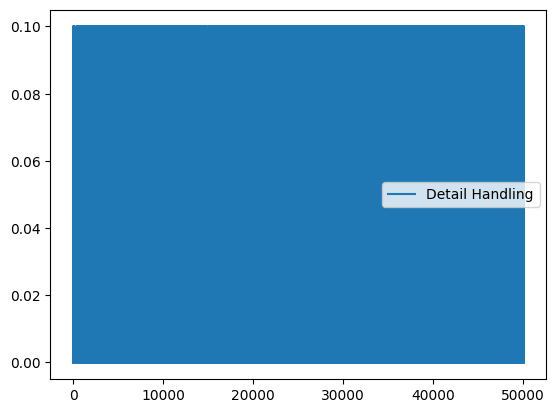

In [ ]:
df.plot(y='Detail Handling')

<Axes: >

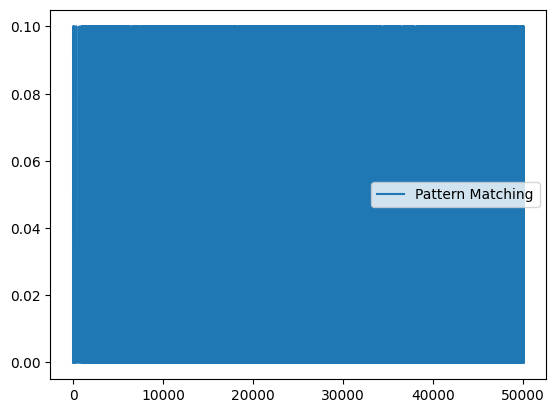

In [ ]:
df.plot(y='Pattern Matching')

<Axes: >

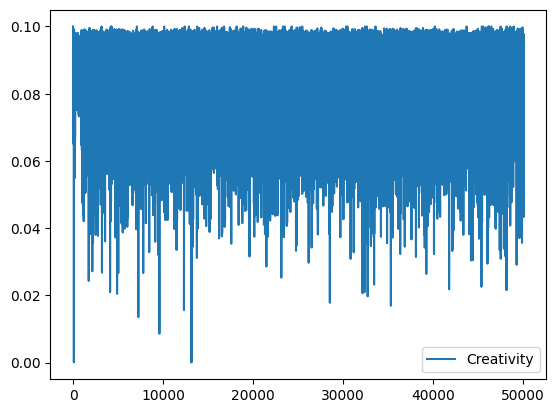

In [ ]:
df.plot(y='Creativity')

<Axes: >

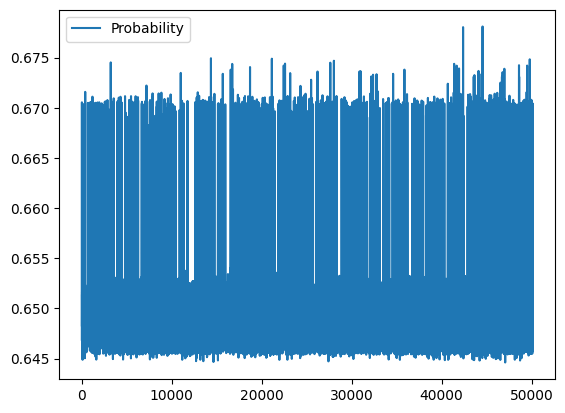

In [ ]:
df.plot(y='Probability')

In [ ]:
alpha

NameError: ignored

<Axes: >

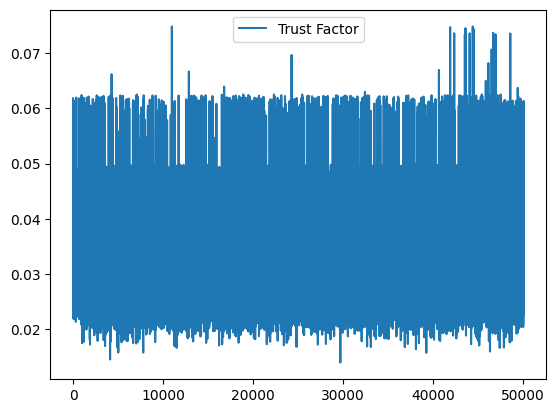

In [ ]:
df.plot(y='Trust Factor')